# Zara Sales Exploratory Data Analysis

### Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [51]:
df = pd.read_csv("../dataset/Zara_sales_EDA.csv", sep=';')

df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [52]:
df.shape

(20252, 17)

### Observation:

In [53]:
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='str')

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  str    
 2   Promotion         20252 non-null  str    
 3   Product Category  20252 non-null  str    
 4   Seasonal          20252 non-null  str    
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  str    
 7   url               20252 non-null  str    
 8   name              20251 non-null  str    
 9   description       20250 non-null  str    
 10  price             20252 non-null  float64
 11  currency          20252 non-null  str    
 12  terms             20252 non-null  str    
 13  section           20252 non-null  str    
 14  season            20252 non-null  str    
 15  material          20252 non-null  str    
 16  origin            20252 non-null  str    
dtypes: f

### Missing Value Analysis

In [55]:
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                1
description         2
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

### Data Cleaning

In [56]:
df.dropna(inplace=True)

In [57]:
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                0
description         0
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

### Duplicate Value Check

In [58]:
import pandas as pd
df.duplicated().sum()

np.int64(0)

In [59]:
df.shape

(20250, 17)

### Statistical Analysis

In [60]:
df.describe()

,Product ID,Sales Volume,price
count,20250.000000,20250.000000,20250.000000
mean,208935.993383,1097.428148,41.950592
std,8949.110701,298.236187,23.381581
min,110075.000000,518.000000,12.000000
25%,204444.250000,849.000000,23.950000
50%,209506.500000,990.000000,35.950000
75%,214568.750000,1364.750000,53.950000
max,219631.000000,1940.000000,134.990000


## Visualization

### Histogram of Product Price

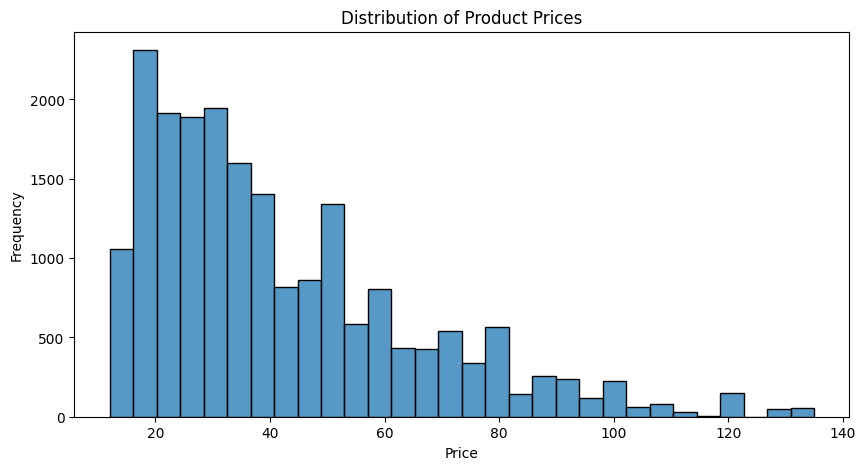

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=30)

plt.title('Distribution of Product Prices')

plt.xlabel('Price')

plt.ylabel('Frequency')

plt.show()

### Count Plot

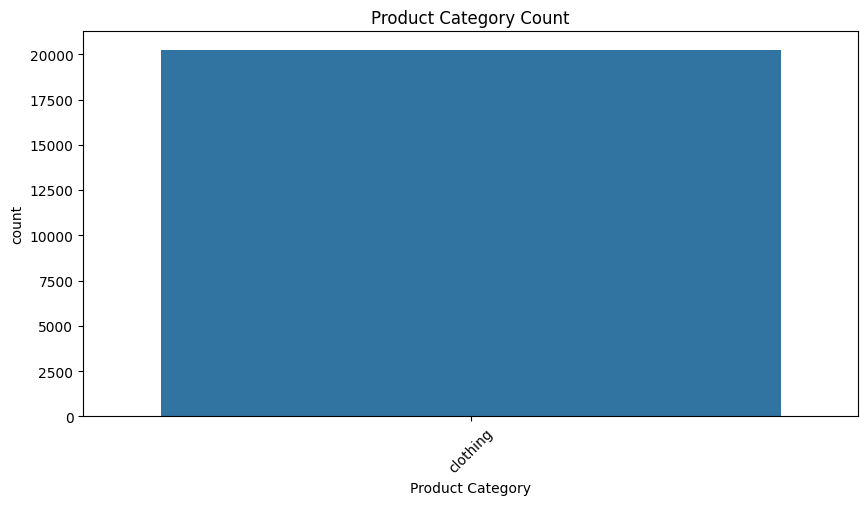

In [62]:
plt.figure(figsize=(10,5))

sns.countplot(x='Product Category', data=df)

plt.title('Product Category Count')

plt.xticks(rotation=45)

plt.show()

### Promotion Count Plot

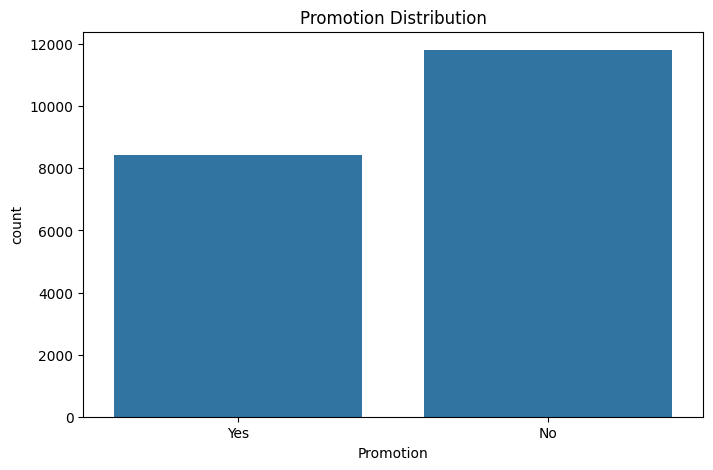

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(x='Promotion', data=df)

plt.title('Promotion Distribution')

plt.show()

### Sales Volume Distribution

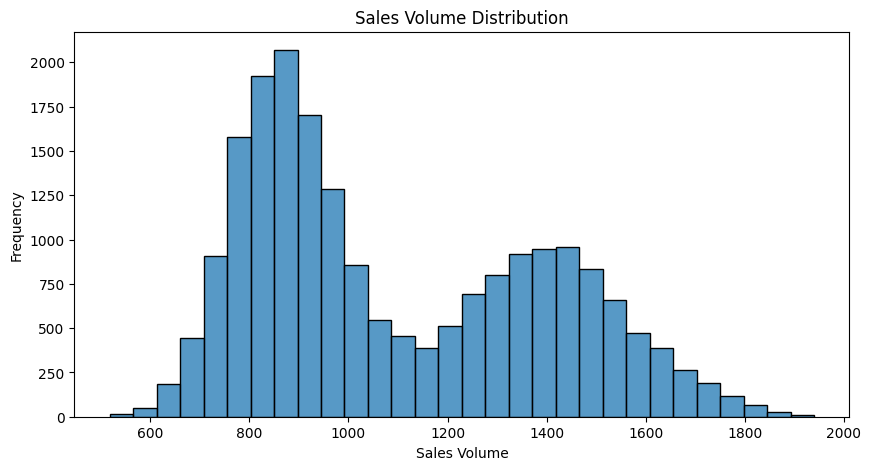

In [64]:
plt.figure(figsize=(10,5))

sns.histplot(df['Sales Volume'], bins=30)

plt.title('Sales Volume Distribution')

plt.xlabel('Sales Volume')

plt.ylabel('Frequency')

plt.show()

In [65]:
# Find out WHAT products fall in each group
low_group = df[df['Sales Volume'] < 1100]
high_group = df[df['Sales Volume'] >= 1100]

# Compare categories
print("LOW SELLERS (Sales Volume < 1100):")
print(low_group['Product Category'].value_counts())

print("\nHIGH SELLERS (Sales Volume >= 1100):")
print(high_group['Product Category'].value_counts())

LOW SELLERS (Sales Volume < 1100):
Product Category
clothing    11695
Name: count, dtype: int64

HIGH SELLERS (Sales Volume >= 1100):
Product Category
clothing    8555
Name: count, dtype: int64


### Box Plot Analysis

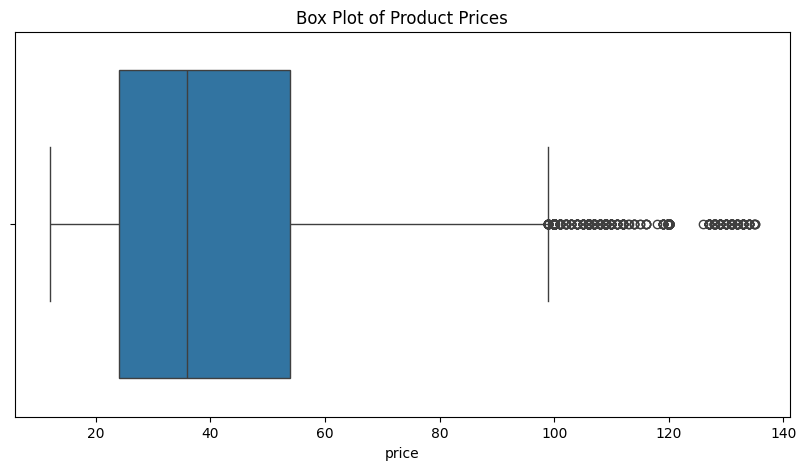

In [66]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['price'])

plt.title('Box Plot of Product Prices')

plt.show()

### Correlation Heatmap

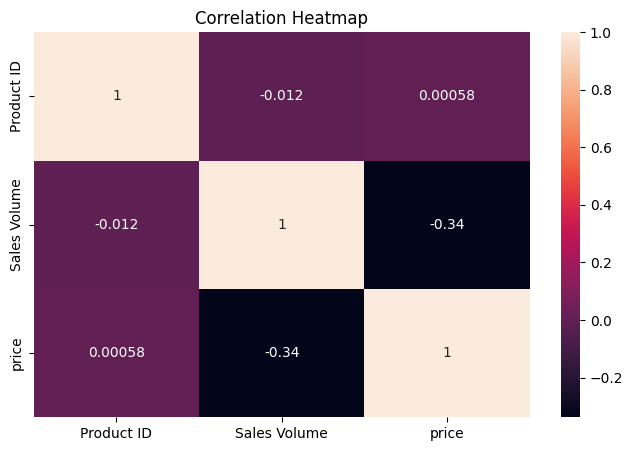

In [67]:
plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True)

plt.title('Correlation Heatmap')

plt.show()

### Scatter Plot Analysis of Price  VS  Sales Volume

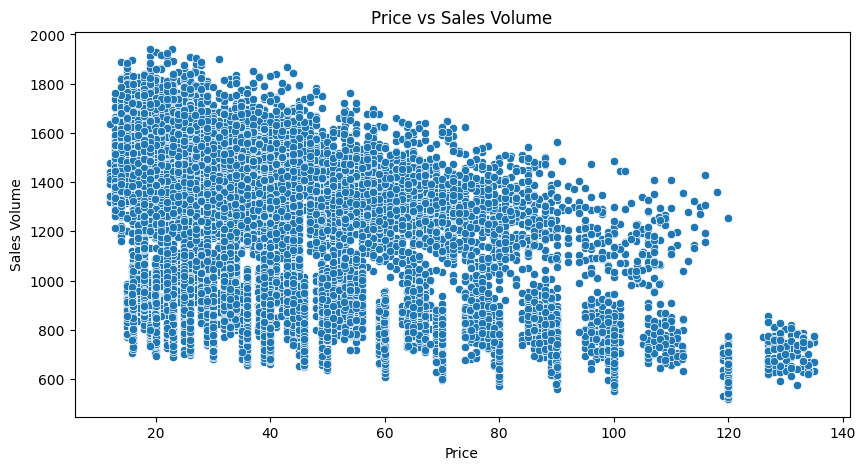

In [68]:
plt.figure(figsize=(10,5))

sns.scatterplot(x='price', y='Sales Volume', data=df)

plt.title('Price vs Sales Volume')

plt.xlabel('Price')

plt.ylabel('Sales Volume')

plt.show()

### Seasonal Analysis

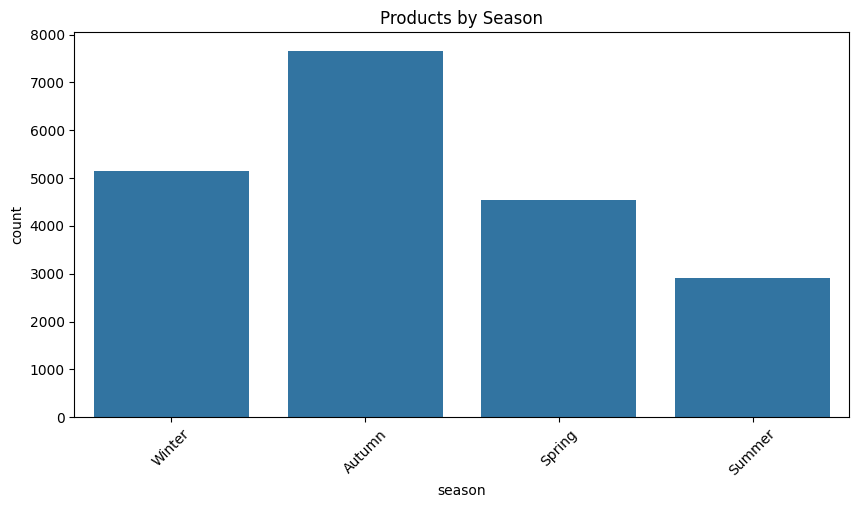

In [69]:
plt.figure(figsize=(10,5))

sns.countplot(x='season', data=df)

plt.title('Products by Season')

plt.xticks(rotation=45)

plt.show()

### Product Position Analysis

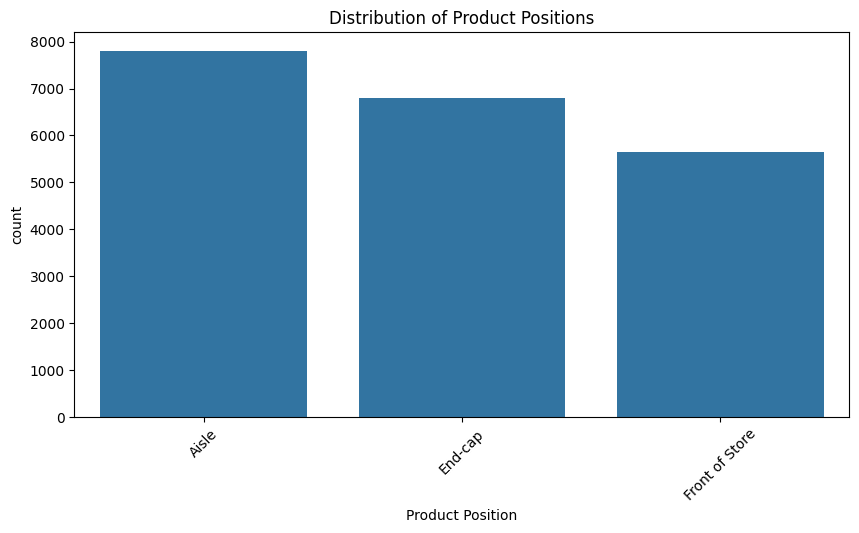

In [70]:
plt.figure(figsize=(10,5))

sns.countplot(x='Product Position', data=df)

plt.title('Distribution of Product Positions')

plt.xticks(rotation=45)

plt.show()

### Price Analysis by Season

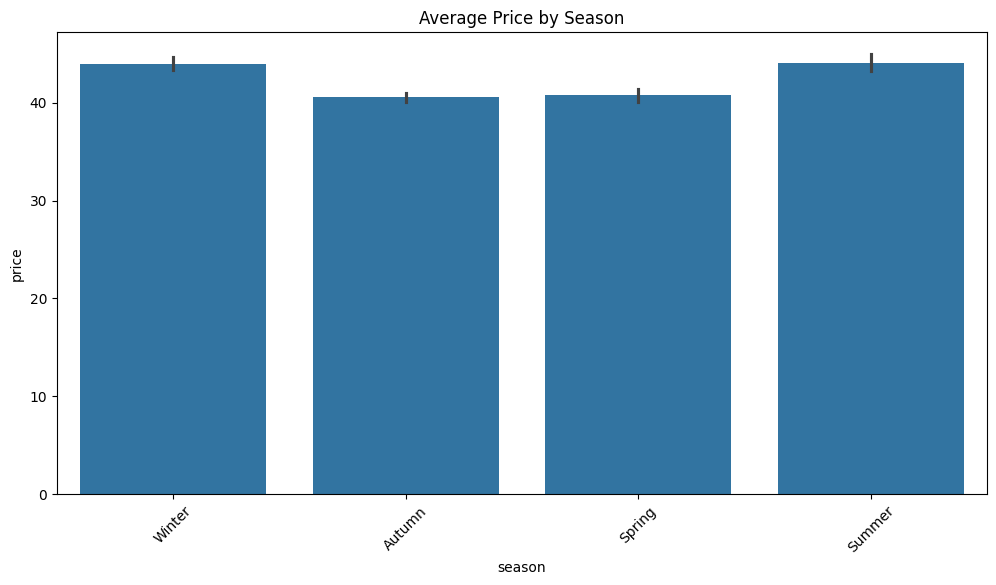

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(x='season', y='price', data=df)

plt.title('Average Price by Season')

plt.xticks(rotation=45)

plt.show()

### Promotion Impact Analysis

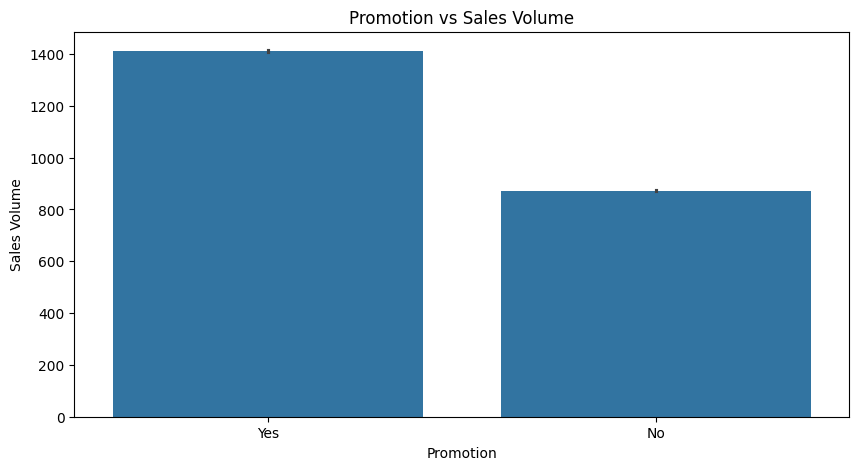

In [72]:
plt.figure(figsize=(10,5))

sns.barplot(x='Promotion', y='Sales Volume', data=df)

plt.title('Promotion vs Sales Volume')

plt.show()

### Final Business Insights

1. Most products belong to the Clothing category, indicating Zara mainly focuses on apparel and fashion products.

2. Product prices are concentrated within a moderate range, while a few premium-priced products act as outliers.

3. Seasonal analysis shows that Zara adjusts product inventory according to seasonal demand patterns.

4. Promotion analysis suggests that promoted products generally achieve higher sales volume, highlighting the effectiveness of marketing strategies.

5. Scatter plot analysis indicates the relationship between product pricing and sales volume.

6. Box plot analysis identified several high-price outliers, representing premium product offerings.

7. Product Position analysis shows how Zara distributes products across categories such as new collections, bestsellers, and core inventory products.

8. Sales volume distribution indicates that only a limited number of products achieve extremely high sales performance.

### Conclusion

This exploratory data analysis project on Zara sales data provided valuable insights into product pricing, sales performance, promotions, seasonal trends, and product positioning strategies.

The project involved:
- data loading,
- data cleaning,
- missing value analysis,
- duplicate checking,
- statistical analysis,
- and data visualization using Python libraries such as Pandas, Matplotlib, and Seaborn.

Different visualizations including histograms, count plots, scatter plots, box plots, heatmaps, and bar charts helped identify important patterns, distributions, and relationships within the dataset.

The analysis revealed that promotions positively impact sales volume, product pricing varies across seasons, and Zara maintains a strong focus on apparel products and new product collections.

Overall, this project demonstrates how exploratory data analysis can support business decision-making related to inventory management, pricing strategy, promotions, and product planning.